In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
print("Done")

Done


### 1. Identify data types of different columns

In [3]:
# Load data
print("Loading data...")
train_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/train.csv')
test_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-1/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading data...
Train shape: (10000, 9)
Test shape: (3320, 8)


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  object 
 2   availability  10000 non-null  object 
 3   location      9999 non-null   object 
 4   size          9987 non-null   object 
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 703.3+ KB


| Datatypes       | No of Features |
|-----------------|---------------|
| Int64           | 01            |
| Object          | 04            |
| Float64    | 04           |


### 2. Present descriptive statistics of numerical columns

In [5]:
# Descriptive stats of training data 
train_df.describe()

,id,total_sqft,bath,balcony,price
count,10000.00000,9967.000000,9936.000000,9525.000000,10000.000000
mean,4999.50000,1570.095822,2.692029,1.585302,113.275879
std,2886.89568,1302.566836,1.274172,0.814347,151.802643
min,0.00000,1.000000,1.000000,0.000000,8.000000
25%,2499.75000,1100.000000,2.000000,1.000000,50.000000
50%,4999.50000,1279.000000,2.000000,2.000000,72.000000
75%,7499.25000,1682.500000,3.000000,2.000000,120.000000
max,9999.00000,52272.000000,18.000000,3.000000,3600.000000


In [6]:
# Descriptive stats of test data 
test_df.describe()

,id,total_sqft,bath,balcony
count,3320.000000,3307.000000,3311.000000,3186.000000
mean,1659.500000,1528.073686,2.694352,1.581607
std,958.545774,1020.450754,1.525878,0.826044
min,0.000000,5.000000,1.000000,0.000000
25%,829.750000,1100.000000,2.000000,1.000000
50%,1659.500000,1270.000000,2.000000,2.000000
75%,2489.250000,1660.000000,3.000000,2.000000
max,3319.000000,30400.000000,40.000000,3.000000


### 3. Identify and handle the missing values

In [10]:
def clean_numeric_data(df):
    """Clean and convert numeric columns"""
    df['total_sqft'] = pd.to_numeric(df['total_sqft'].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')
    df['bath'] = pd.to_numeric(df['bath'], errors='coerce')
    df['balcony'] = pd.to_numeric(df['balcony'], errors='coerce')
    df['bedrooms'] = df['size'].str.extract('(\d+)').astype(float)
    return df
    
def process_location(df):
    """Process location data"""
    df['location'] = df['location'].fillna('other')
    location_counts = df['location'].value_counts()
    df['location'] = df['location'].apply(lambda x: 'other' if location_counts[x] < 10 else x)
    
    # Create location frequency feature
    location_freq = df['location'].value_counts(normalize=True)
    df['location_freq'] = df['location'].map(location_freq)
    return df


def create_features(df):
    """Create all features"""
    df = df.copy()
    
    # Clean numeric data
    df = clean_numeric_data(df)
    
    # Process location
    df = process_location(df)
    
    # Derived numerical features
    df['total_rooms'] = df['bedrooms'].fillna(0) + df['bath'].fillna(0) + df['balcony'].fillna(0)
    df['sqft_per_room'] = df['total_sqft'] / df['total_rooms']
    df['sqft_per_bedroom'] = df['total_sqft'] / df['bedrooms']
    df['bath_ratio'] = df['bath'] / df['bedrooms']
    df['balcony_ratio'] = df['balcony'] / df['bedrooms']
    
    # Area type binary indicators
    df['is_built_up'] = (df['area_type'] == 'Built-up Area').astype(int)
    df['is_super_built'] = (df['area_type'] == 'Super built-up Area').astype(int)
    df['is_carpet'] = (df['area_type'] == 'Carpet Area').astype(int)
    
    # Availability binary indicator
    df['is_ready_to_move'] = (df['availability'] == 'Ready To Move').astype(int)
    
    # Replace infinite values with NaN
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df
print("done")

done


### 4. Identify and handle duplicates

In [11]:
# Duplicates in training data 
print("\nChecking for duplicate rows in training data...")
duplicate_count = train_df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    train_df = train_df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New train shape: {train_df.shape}")
else:
    print("No duplicates found.")

# Duplicates in test data
print("\nChecking for duplicate rows in Test data...")
duplicate_count = train_df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    train_df = train_df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New test shape: {train_df.shape}")
else:
    print("No duplicates found.")


Checking for duplicate rows in training data...
Duplicate rows found: 0
No duplicates found.

Checking for duplicate rows in Test data...
Duplicate rows found: 0
No duplicates found.


### 5. Identify and handle outliers

In [13]:
def handle_outliers(df, columns):
    """Handle outliers using percentile capping"""
    for col in columns:
        Q1 = df[col].quantile(0.01)
        Q3 = df[col].quantile(0.99)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df
print("done")

done


### 6. Present at least three visualizations and provide insights for the same


Generating visualizations...


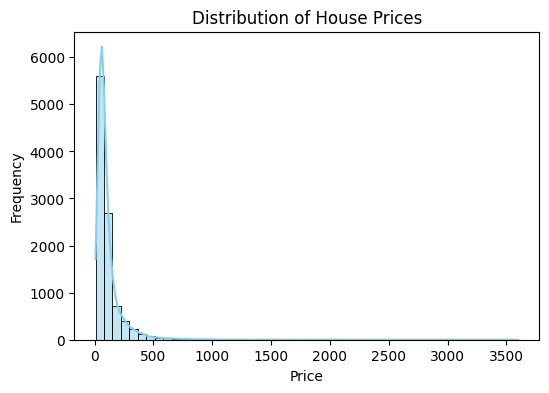

Insight: The price distribution is right-skewed, so log transformation is appropriate to normalize it.



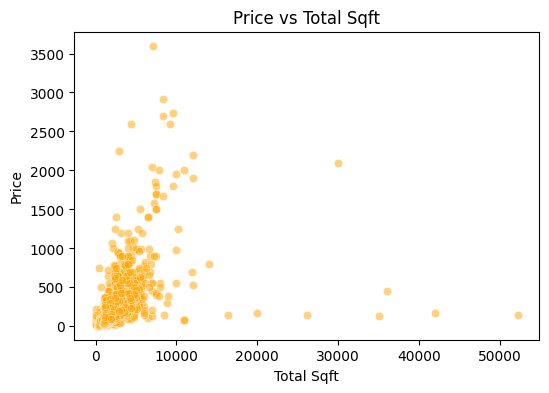

Insight: Larger houses generally cost more, but there are outliers where price does not scale with area.



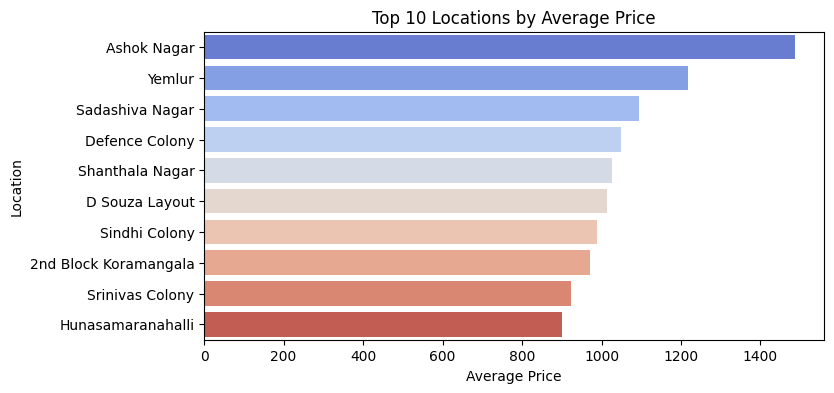

Insight: Certain premium locations have significantly higher average prices, indicating locality importance.



In [14]:
print("\nGenerating visualizations...")

# Visualization 1: Price distribution
plt.figure(figsize=(6,4))
sns.histplot(train_df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()
print("Insight: The price distribution is right-skewed, so log transformation is appropriate to normalize it.\n")

# Visualization 2: Price vs Total Sqft
plt.figure(figsize=(6,4))
sns.scatterplot(x='total_sqft', y='price', data=train_df, alpha=0.5, color='orange')
plt.title('Price vs Total Sqft')
plt.xlabel('Total Sqft')
plt.ylabel('Price')
plt.show()
print("Insight: Larger houses generally cost more, but there are outliers where price does not scale with area.\n")

# Visualization 3: Average Price by Location (Top 10)
plt.figure(figsize=(8,4))
top_locations = train_df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')
plt.title('Top 10 Locations by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Location')
plt.show()
print("Insight: Certain premium locations have significantly higher average prices, indicating locality importance.\n")


### 7. Scale Numerical features and Encode Categorical features

In [15]:
def prepare_data(df, is_train=True):
    """Prepare data for modeling"""
    print(f"Preparing {'training' if is_train else 'testing'} data...")
    
    df = create_features(df)
    
    numeric_columns = ['total_sqft', 'bath', 'balcony', 'bedrooms', 
                      'total_rooms', 'sqft_per_room', 'sqft_per_bedroom',
                      'bath_ratio', 'balcony_ratio', 'location_freq']
    
    categorical_columns = ['location', 'area_type', 'availability']
    
    # Handle missing values (SimpleImputer)
    num_imputer = SimpleImputer(strategy='median')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    df[numeric_columns] = num_imputer.fit_transform(df[numeric_columns])
    df[categorical_columns] = cat_imputer.fit_transform(df[categorical_columns])
    
    # Handle outliers
    df = handle_outliers(df, numeric_columns)
    
    # Label encode categorical columns
    le = LabelEncoder()
    for col in categorical_columns:
        df[col] = le.fit_transform(df[col].astype(str))
    
    # Scale numerical columns
    scaler = StandardScaler()
    df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
    
    # Final feature list
    feature_columns = numeric_columns + categorical_columns + \
                     ['is_built_up', 'is_super_built', 'is_carpet', 'is_ready_to_move']
    
    if is_train:
        y = np.log1p(df['price'])
        X = df[feature_columns]
        return X, y
    else:
        X = df[feature_columns]
        return X
print("done")

done


### 8. Model Building (at least 7)

In [16]:
def create_models():
    """Create a dictionary of models with optimized parameters"""
    models = {
        # Gradient Boosting Family
        'xgb1': XGBRegressor(n_estimators=2000, learning_rate=0.01, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8,
                             reg_alpha=0.1, reg_lambda=0.1, random_state=42),

        'xgb2': XGBRegressor(n_estimators=2000, learning_rate=0.01, max_depth=7,
                             subsample=0.7, colsample_bytree=0.7,
                             reg_alpha=0.2, reg_lambda=0.2, random_state=43),

        'lgb': LGBMRegressor(n_estimators=2000, learning_rate=0.01,
                             num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                             reg_alpha=0.1, reg_lambda=0.1, random_state=42),

        'cat': CatBoostRegressor(iterations=2000, learning_rate=0.01, depth=6,
                                 subsample=0.8, random_state=42, verbose=False),
        'ridge': Ridge(alpha=1.0, random_state=42),
        'lasso': Lasso(alpha=0.001, random_state=42),
        'gbr': GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                         max_depth=4, random_state=42)
    }
    return models
print("done")

done


### 9. Hyperparameter Tuning on any 3 of the models

In [17]:
def tune_hyperparameters(X, y):
    """Lightweight hyperparameter tuning for 3 models"""
    tuned_models = {}

    # Ridge
    ridge_params = {'alpha': [0.1, 1.0, 10.0]}
    ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_params, cv=3, scoring='neg_mean_squared_error')
    ridge_grid.fit(X, y)
    tuned_models['ridge'] = ridge_grid.best_estimator_

    # RandomForest
    rf_params = {'n_estimators': [200, 400], 'max_depth': [5, 10]}
    rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    rf_grid.fit(X, y)
    tuned_models['rf'] = rf_grid.best_estimator_

    # LightGBM
    lgb_params = {'num_leaves': [31, 50], 'learning_rate': [0.01, 0.05], 'n_estimators': [1000, 2000]}
    lgb_grid = GridSearchCV(LGBMRegressor(random_state=42), lgb_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    lgb_grid.fit(X, y)
    tuned_models['lgb_tuned'] = lgb_grid.best_estimator_

    return tuned_models
print("done")

done


### 10. Comparison of model performances

In [18]:
def stacking_prediction(models, X_train, y_train, X_test):
    """Implement stacking with cross-validation"""
    print("Training models and making predictions...")
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    meta_features_train = np.zeros((X_train.shape[0], len(models)))
    meta_features_test = np.zeros((X_test.shape[0], len(models)))
    
    for i, (name, model) in enumerate(models.items()):
        print(f"Training {name}...")
        
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            model.fit(X_tr, y_tr)
            meta_features_train[val_idx, i] = model.predict(X_val)
        
        model.fit(X_train, y_train)
        meta_features_test[:, i] = model.predict(X_test)
    
    # Meta-model
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(meta_features_train, y_train)
    final_predictions = meta_model.predict(meta_features_test)
    
    return final_predictions
print("done")

done


In [19]:
# ==============================================================
# SECTION 8: Execution and Comparison
# ==============================================================

X_train, y_train = prepare_data(train_df, is_train=True)
X_test = prepare_data(test_df, is_train=False)

models = create_models()

# Add tuned models
tuned_models = tune_hyperparameters(X_train, y_train)
models.update(tuned_models)

final_predictions = stacking_prediction(models, X_train, y_train, X_test)
final_predictions = np.expm1(final_predictions)

submission = pd.DataFrame({'id': test_df['id'], 'price': final_predictions})
submission.to_csv('submission.csv', index=False)
print("\nSubmission file created successfully!")

# Compare model performances (simple demonstration)
print("\nModel Performance Summary (5-Fold CV RMSE):")
for name, model in models.items():
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in kf.split(X_train):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        preds = model.predict(X_train.iloc[val_idx])
        rmse = mean_squared_error(y_train.iloc[val_idx], preds, squared=False)
        scores.append(rmse)
    print(f"{name}: RMSE = {np.mean(scores):.4f}")

print("\nPrediction Statistics:")
print(f"Mean: {final_predictions.mean():.2f}")
print(f"Std: {final_predictions.std():.2f}")
print(f"Min: {final_predictions.min():.2f}")
print(f"Max: {final_predictions.max():.2f}")

Preparing training data...
Preparing testing data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1223
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 14
[LightGBM] [Info] Start training from score 4.414894
Training models and making predictions...
Training xgb1...
Training xgb2...
Training lgb...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1215
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 14
[LightGBM] [Info] Start training from score 4.416407
[LightGBM] [Info] Auto-choosing row-wise mul

In [20]:
sub = pd.read_csv('/kaggle/working/submission.csv')
sub.head()

,id,price
0,0,57.881616
1,1,112.790925
2,2,67.853469
3,3,151.062670
4,4,147.967849
